# You have been hired by the Kenya Metrological department as a Data scientist. The ICT manager has tasked you with the job of analyzing weather data for major cities in Kenya. You are required to gather, process, and store the data using various data formats and tools available in Pandas.

## Tasks

- Use the OpenWeatherMap API to fetch current weather data for the following Kenyan cities: Nairobi, Mombasa, Kisumu, Nakuru, and Eldoret.
- Store the collected data in a Pandas DataFrame.
- Save the DataFrame to a CSV file.
-  a simple analysis to find the city with the highest temperature.
- Create a report summarizing the weather conditions for each city.

In [1]:
import pandas as pd
import numpy as np

In [31]:
import requests
import pandas as pd

# API key and endpoint
api_key = 'f4aaacf29976bba0a688d364c5e511c3'
base_url = 'https://api.openweathermap.org/data/2.5/weather'

# Kenyan cities with coordinates (lat, lon)
cities = {
    'Nairobi': (1.2921, 36.8219),
    'Mombasa': (-4.0435, 39.6682),
    'Kisumu': (-0.0917, 34.7680),
    'Nakuru': (-0.3167, 36.0833),
    'Eldoret': (0.3167, 35.2833),
    'Thika': (-1.0333, 37.0833),
    'Nyeri': (-0.4167, 36.9500),
    'Meru': (0.0500, 37.6500),
    'Garissa': (-0.4500, 39.6500),
    'Kitale': (1.0167, 35.0000),
    'Nyanza': (-0.5000, 36.9500),
    'Machakos': (-1.5167, 37.2667),
    'Kakamega': (0.2833, 34.7500),
    'Busia': (0.4500, 34.1000),
    'Lamu': (-2.2667, 40.9000),
    'Wajir': (1.7500, 40.0667),
    'Ngong': (-1.2833, 36.8167),
    'Kajiado': (-1.8500, 36.7833),
    'Embu': (-0.5333, 37.4500)

}

# List to store city weather data
weather_list = []

# Fetch weather data for each city
for city, (lat, lon) in cities.items():
    params = {
        'lat': lat,
        'lon': lon,
        'units': 'metric',
        'appid': api_key
    }
    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
        city_weather = {
            'City': city,
            'Temperature (°C)': data['main']['temp'],
            'Humidity (%)': data['main']['humidity'],
            'Pressure (hPa)': data['main']['pressure'],
            'Weather': data['weather'][0]['description'],
            'Wind Speed (m/s)': data['wind']['speed'],
            'Rain (mm last 1h)': data['rain']['1h'] if 'rain' in data and '1h' in data['rain'] else 0
        }
        weather_list.append(city_weather)
    else:
        print(f'Failed to get data for {city}')

# Create DataFrame
weather_df = pd.DataFrame(weather_list)

# Save DataFrame to CSV
weather_df.to_csv('kenya_weather.csv', index=False)

# Report: Summary of all cities
print("Weather Summary Report for Major Kenyan Cities:")
print(weather_df)

Weather Summary Report for Major Kenyan Cities:
        City  Temperature (°C)  Humidity (%)  Pressure (hPa)          Weather  \
0    Nairobi             29.98            37            1008  overcast clouds   
1    Mombasa             32.22            66            1008       light rain   
2     Kisumu             27.12            54            1008       light rain   
3     Nakuru             23.77            53            1010       light rain   
4    Eldoret             23.47            57            1012       light rain   
5      Thika             25.52            55            1009       light rain   
6      Nyeri             23.51            61            1010       light rain   
7       Meru             23.18            68            1011       light rain   
8    Garissa             34.18            41            1007       light rain   
9     Kitale             21.28            55            1010       light rain   
10    Nyanza             23.90            58            1010 

In [14]:
max_temp_row = weather_df.loc[weather_df['Temperature (°C)'].idxmax()]
print(f"City with highest temperature: {max_temp_row['City']} ({max_temp_row['Temperature (°C)']}°C)\n")
print("Weather Summary: " + str(weather_df.shape[0]) + "cities")
weather_df.sort_values(by='Rain (mm last 1h)', ascending=False)


City with highest temperature: Garissa (34.18°C)

Weather Summary: 16cities


,City,Temperature (°C),Humidity (%),Pressure (hPa),Weather,Wind Speed (m/s),Rain (mm last 1h)
11,Machakos,23.33,63,1010,moderate rain,3.08,1.22
7,Meru,23.18,68,1011,light rain,2.72,0.93
6,Nyeri,23.51,61,1010,light rain,2.62,0.88
4,Eldoret,23.47,57,1012,light rain,3.60,0.80
3,Nakuru,23.77,53,1010,light rain,3.53,0.52
10,Nyanza,23.90,58,1010,light rain,2.67,0.52
5,Thika,25.52,55,1009,light rain,3.12,0.50
12,Kakamega,23.32,59,1009,light rain,1.66,0.38
1,Mombasa,32.22,66,1008,light rain,5.14,0.31
2,Kisumu,28.77,54,1008,light rain,4.12,0.21


In [15]:
#analyzing and giving conclusion summarry describing the rains, temperature and humidity
def analyze_weather_data(df):
    summary = "Weather Analysis Summary:\n"
    
    # Overall weather conditions
    avg_temp = df['Temperature (°C)'].mean()
    avg_humidity = df['Humidity (%)'].mean()
    summary += f"- Average Temperature: {avg_temp:.2f}°C\n"
    summary += f"- Average Humidity: {avg_humidity:.2f}%\n"
    
    # Flood alert analysis
    flood_risk_cities = df[df['Rain (mm last 1h)'] >= 20]
    if not flood_risk_cities.empty:
        summary += "- Cities at Flood Risk:\n"
        for _, row in flood_risk_cities.iterrows():
            summary += f"  - {row['City']} with {row['Rain (mm last 1h)']} mm of rain\n"
    else:
        summary += "- No cities currently at high flood risk.\n"
    
    # Actionable insights
    if not flood_risk_cities.empty:
        summary += "Recommended Actions:\n"
        summary += "- Residents in high-risk cities should stay informed through local news and authorities.\n"
        summary += "- Prepare emergency kits and have evacuation plans ready.\n"
        summary += "- Avoid traveling to or through high-risk areas during heavy rainfall.\n"
    
    return summary

analysis_summary = analyze_weather_data(weather_df)
print(analysis_summary)

Weather Analysis Summary:
- Average Temperature: 26.79°C
- Average Humidity: 54.94%
- No cities currently at high flood risk.



In [16]:
#predict the possibility of heavy rains in the next 24 hours based on current weather conditions
def predict_heavy_rains(df):
    predictions = "Heavy Rain Prediction for the Next 24 Hours:\n"
    
    for _, row in df.iterrows():
        city = row['City']
        rain = row['Rain (mm last 1h)']
        humidity = row['Humidity (%)']
        temp = row['Temperature (°C)']
        
        # Simple heuristic for prediction
        if rain > 10 and humidity > 80 and temp < 25:
            predictions += f"- {city}: High chance of heavy rains.\n"
        elif rain > 5 and humidity > 70:
            predictions += f"- {city}: Moderate chance of heavy rains.\n"
        else:
            predictions += f"- {city}: Low chance of heavy rains.\n"
    
    return predictions
rain_predictions = predict_heavy_rains(weather_df)
print(rain_predictions)

Heavy Rain Prediction for the Next 24 Hours:
- Nairobi: Low chance of heavy rains.
- Mombasa: Low chance of heavy rains.
- Kisumu: Low chance of heavy rains.
- Nakuru: Low chance of heavy rains.
- Eldoret: Low chance of heavy rains.
- Thika: Low chance of heavy rains.
- Nyeri: Low chance of heavy rains.
- Meru: Low chance of heavy rains.
- Garissa: Low chance of heavy rains.
- Kitale: Low chance of heavy rains.
- Nyanza: Low chance of heavy rains.
- Machakos: Low chance of heavy rains.
- Kakamega: Low chance of heavy rains.
- Busia: Low chance of heavy rains.
- Lamu: Low chance of heavy rains.
- Wajir: Low chance of heavy rains.



In [17]:
#check weather conditions in the next 4 days from the open weather Api
forecast_url = 'https://api.openweathermap.org/data/2.5/forecast'
forecast_list = []
for city, (lat, lon) in cities.items():
    params = {
        'lat': lat,
        'lon': lon,
        'units': 'metric',
        'appid': api_key
    }
    response = requests.get(forecast_url, params=params)
    if response.status_code == 200:
        data = response.json()
        for forecast in data['list']:
            forecast_entry = {
                'City': city,
                'DateTime': forecast['dt_txt'],
                'Temperature (°C)': forecast['main']['temp'],
                'Humidity (%)': forecast['main']['humidity'],
                'Pressure (hPa)': forecast['main']['pressure'],
                'Weather': forecast['weather'][0]['description'],
                'Wind Speed (m/s)': forecast['wind']['speed'],
                'Rain (mm last 3h)': forecast['rain']['3h'] if 'rain' in forecast and '3h' in forecast['rain'] else 0
            }
            forecast_list.append(forecast_entry)
    else:
        print(f'Failed to get forecast data for {city}')
forecast_df = pd.DataFrame(forecast_list)
forecast_df.to_csv('kenya_weather_forecast.csv', index=False)
print("Weather Forecast for the Next 4 Days:")
print(forecast_df)

Weather Forecast for the Next 4 Days:
        City             DateTime  Temperature (°C)  Humidity (%)  \
0    Nairobi  2026-03-18 12:00:00             29.08            40   
1    Nairobi  2026-03-18 15:00:00             27.49            48   
2    Nairobi  2026-03-18 18:00:00             24.34            65   
3    Nairobi  2026-03-18 21:00:00             21.74            77   
4    Nairobi  2026-03-19 00:00:00             21.14            77   
..       ...                  ...               ...           ...   
635    Wajir  2026-03-22 21:00:00             28.41            57   
636    Wajir  2026-03-23 00:00:00             26.47            69   
637    Wajir  2026-03-23 03:00:00             25.73            74   
638    Wajir  2026-03-23 06:00:00             27.50            65   
639    Wajir  2026-03-23 09:00:00             30.55            46   

     Pressure (hPa)          Weather  Wind Speed (m/s)  Rain (mm last 3h)  
0              1007  overcast clouds              6.68   

Text(0.5, 1.0, 'Current Temperature in Major Kenyan Cities')

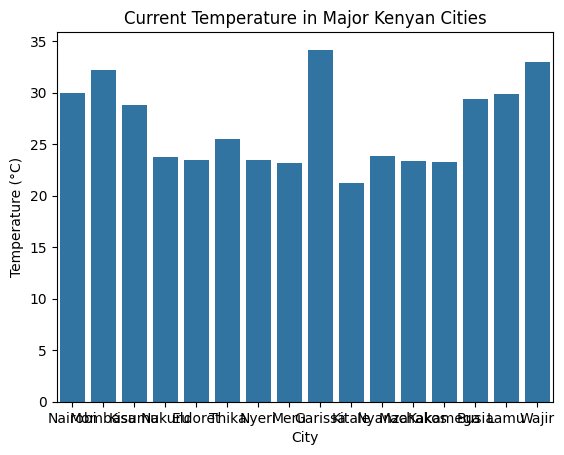

In [18]:
#visualization of the weather data using matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

ggplot = sns.barplot(x='City', y='Temperature (°C)', data=weather_df)
ggplot.set_title('Current Temperature in Major Kenyan Cities')
# 

Text(0.5, 1.0, 'Current Humidity in Major Kenyan Cities')

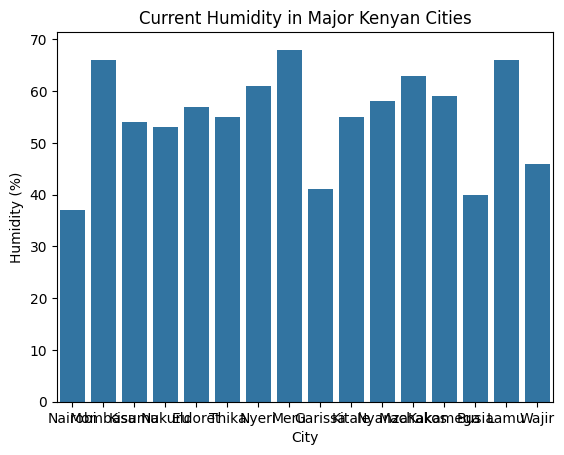

In [19]:
ggplot = sns.barplot(x='City', y='Humidity (%)', data=weather_df)
ggplot.set_title('Current Humidity in Major Kenyan Cities')

In [32]:
#based on the expected rains from the forecast data possibility of heavy rains in the next 24 hours
def predict_heavy_rains_forecast(df):
    predictions = "Heavy Rain Prediction for the Next 24 Hours Based on Forecast:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        max_rain = city_forecast['Rain (mm last 3h)'].max()
        avg_humidity = city_forecast['Humidity (%)'].mean()
        avg_temp = city_forecast['Temperature (°C)'].mean()
        
        if max_rain > 15 and avg_humidity > 80 and avg_temp < 25:
            predictions += f"- {city}: High chance of heavy rains.\n"
        elif max_rain > 5 and avg_humidity > 70:
            predictions += f"- {city}: Moderate chance of heavy rains.\n"
        else:
            predictions += f"- {city}: Low chance of heavy rains.\n"
    
    return predictions
forecast_rain_predictions = predict_heavy_rains_forecast(forecast_df)
print(forecast_rain_predictions)

#chances of experiencing floods in the next 24 hours based on the forecast data
def predict_flood_risk_forecast(df):
    predictions = "Flood Risk Prediction for the Next 24 Hours Based on Forecast:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        max_rain = city_forecast['Rain (mm last 3h)'].max()
        
        if max_rain > 30:
            predictions += f"- {city}: High flood risk.\n"
        elif max_rain > 15:
            predictions += f"- {city}: Moderate flood risk.\n"
        else:
            predictions += f"- {city}: Low flood risk.\n"
    
    return predictions
flood_risk_predictions = predict_flood_risk_forecast(forecast_df)
print(flood_risk_predictions)

Heavy Rain Prediction for the Next 24 Hours Based on Forecast:
- Nairobi: Low chance of heavy rains.
- Mombasa: Moderate chance of heavy rains.
- Kisumu: Moderate chance of heavy rains.
- Nakuru: Moderate chance of heavy rains.
- Eldoret: Moderate chance of heavy rains.
- Thika: Low chance of heavy rains.
- Nyeri: Low chance of heavy rains.
- Meru: Low chance of heavy rains.
- Garissa: Low chance of heavy rains.
- Kitale: Moderate chance of heavy rains.
- Nyanza: Low chance of heavy rains.
- Machakos: Low chance of heavy rains.
- Kakamega: High chance of heavy rains.
- Busia: Moderate chance of heavy rains.
- Lamu: Low chance of heavy rains.
- Wajir: Low chance of heavy rains.

Flood Risk Prediction for the Next 24 Hours Based on Forecast:
- Nairobi: Low flood risk.
- Mombasa: Low flood risk.
- Kisumu: Low flood risk.
- Nakuru: Low flood risk.
- Eldoret: Low flood risk.
- Thika: Low flood risk.
- Nyeri: Low flood risk.
- Meru: Low flood risk.
- Garissa: Low flood risk.
- Kitale: Low fl

In [34]:
#expected rains in the afternoon
def predict_afternoon_rains(df):
    predictions = "Afternoon Rain Prediction for the Next 4 Days:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        afternoon_forecast = city_forecast[city_forecast['DateTime'].str.contains('15:00:00')]
        
        if not afternoon_forecast.empty:
            max_rain = afternoon_forecast['Rain (mm last 3h)'].max()
            if max_rain > 10:
                predictions += f"- {city}: High chance of rain in the afternoon.\n"
            elif max_rain > 5:
                predictions += f"- {city}: Moderate chance of rain in the afternoon.\n"
            else:
                predictions += f"- {city}: Low chance of rain in the afternoon.\n"
        else:
            predictions += f"- {city}: No forecast data for the afternoon.\n"
    
    return predictions
afternoon_rain_predictions = predict_afternoon_rains(forecast_df)
print(afternoon_rain_predictions)

Afternoon Rain Prediction for the Next 4 Days:
- Nairobi: Low chance of rain in the afternoon.
- Mombasa: Low chance of rain in the afternoon.
- Kisumu: High chance of rain in the afternoon.
- Nakuru: Moderate chance of rain in the afternoon.
- Eldoret: Low chance of rain in the afternoon.
- Thika: Low chance of rain in the afternoon.
- Nyeri: Low chance of rain in the afternoon.
- Meru: Low chance of rain in the afternoon.
- Garissa: Low chance of rain in the afternoon.
- Kitale: High chance of rain in the afternoon.
- Nyanza: Low chance of rain in the afternoon.
- Machakos: Low chance of rain in the afternoon.
- Kakamega: High chance of rain in the afternoon.
- Busia: Low chance of rain in the afternoon.
- Lamu: Low chance of rain in the afternoon.
- Wajir: Low chance of rain in the afternoon.



In [35]:
#chances or raining and flooding in Nairobi in the afternoon

def predict_afternoon_rains_and_floods(df):
    predictions = "Afternoon Rain and Flood Risk Prediction for the Next 4 Days:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        afternoon_forecast = city_forecast[city_forecast['DateTime'].str.contains('15:00:00')]
        
        if not afternoon_forecast.empty:
            max_rain = afternoon_forecast['Rain (mm last 3h)'].max()
            if max_rain > 15:
                predictions += f"- {city}: High chance of rain and flood risk in the afternoon.\n"
            elif max_rain > 5:
                predictions += f"- {city}: Moderate chance of rain and flood risk in the afternoon.\n"
            else:
                predictions += f"- {city}: Low chance of rain and flood risk in the afternoon.\n"
        else:
            predictions += f"- {city}: No forecast data for the afternoon.\n"
    
    return predictions
afternoon_prediction = predict_afternoon_rains_and_floods(forecast_df)
print(afternoon_prediction)

Afternoon Rain and Flood Risk Prediction for the Next 4 Days:
- Nairobi: Low chance of rain and flood risk in the afternoon.
- Mombasa: Low chance of rain and flood risk in the afternoon.
- Kisumu: Moderate chance of rain and flood risk in the afternoon.
- Nakuru: Moderate chance of rain and flood risk in the afternoon.
- Eldoret: Low chance of rain and flood risk in the afternoon.
- Thika: Low chance of rain and flood risk in the afternoon.
- Nyeri: Low chance of rain and flood risk in the afternoon.
- Meru: Low chance of rain and flood risk in the afternoon.
- Garissa: Low chance of rain and flood risk in the afternoon.
- Kitale: Moderate chance of rain and flood risk in the afternoon.
- Nyanza: Low chance of rain and flood risk in the afternoon.
- Machakos: Low chance of rain and flood risk in the afternoon.
- Kakamega: High chance of rain and flood risk in the afternoon.
- Busia: Low chance of rain and flood risk in the afternoon.
- Lamu: Low chance of rain and flood risk in the af

In [36]:
#Niarobi evening rain and flood risk prediction
#Nairobi floods is highly influenced by rains From Ngong
Ngong_forecast = forecast_df[forecast_df['City'] == 'Ngong']
ngong_evening_forecast = Ngong_forecast[Ngong_forecast['DateTime'].str.contains('18:00:00')]
if not ngong_evening_forecast.empty:
    max_rain = ngong_evening_forecast['Rain (mm last 3h)'].max()
    if max_rain > 10:
        print("Ngong: High chance of rain and flood risk in the evening.")
    elif max_rain > 5:
        print("Ngong: Moderate chance of rain and flood risk in the evening.")
    else:
        print("Ngong: Low chance of rain and flood risk in the evening.")
nairobi_forecast = forecast_df[forecast_df['City'] == 'Nairobi']
nairobi_evening_forecast = nairobi_forecast[nairobi_forecast['DateTime'].str.contains('18:00:00')]
if not nairobi_evening_forecast.empty:
    max_rain = nairobi_evening_forecast['Rain (mm last 3h)'].max()
    if max_rain > 5:
        print("Nairobi: High chance of rain and flood risk in the evening.")
    elif max_rain > 2:
        print("Nairobi: Moderate chance of rain and flood risk in the evening.")
    else:
        print("Nairobi: Low chance of rain and flood risk in the evening.")

Nairobi: Moderate chance of rain and flood risk in the evening.


In [37]:
import pandas as pd

def get_integrated_flood_alert(forecast_df):
    # Filter for the 18:00 (6 PM) evening window
    evening_df = forecast_df[forecast_df['DateTime'].str.contains('18:00:00')]
    
    if evening_df.empty:
        return "No evening forecast data found."

    # Get max rain values for both
    ngong_rain = evening_df[evening_df['City'] == 'Ngong']['Rain (mm last 3h)'].max()
    nrb_rain = evening_df[evening_df['City'] == 'Nairobi']['Rain (mm last 3h)'].max()

    # Determine individual risk levels based on your thresholds
    ngong_high = ngong_rain > 10
    nrb_high = nrb_rain > 5

    print(f"--- 18:00 Forecast: Ngong ({ngong_rain}mm) | Nairobi ({nrb_rain}mm) ---")

    # --- ALERT LOGIC ---
    if ngong_high and nrb_high:
        # Both areas at peak risk
        return "🚨 RED ALERT: MAJOR FLOODING LIKELY. Heavy upstream runoff from Ngong Hills meets saturated city drains. Avoid South C, CBD, and major highways."
    
    elif ngong_high:
        # Risk primarily from the hills (Riverine Flood Risk)
        return "⚠️ AMBER ALERT: RIVERINE RISK. Heavy rain in the hills. Expect Ngong and Mbagathi Rivers to swell in 1-2 hours. High risk for Kibera and South B/C."
    
    elif nrb_high:
        # Risk primarily from local city drainage (Flash Flood Risk)
        return "⚠️ YELLOW ALERT: FLASH FLOODING. Poor city drainage will cause immediate traffic snarls. Avoid underpasses and known blackspots."
    
    else:
        return "✅ STATUS: Standard monitoring. No major integrated flood surge expected tonight."

# Usage
print(get_integrated_flood_alert(forecast_df))


--- 18:00 Forecast: Ngong (nanmm) | Nairobi (3.45mm) ---
✅ STATUS: Standard monitoring. No major integrated flood surge expected tonight.


In [38]:
import pandas as pd

def check_flood_alerts(forecast_df):
    # Filter for today/tomorrow evening window (6 PM)
    evening_df = forecast_df[forecast_df['DateTime'].str.contains('18:00:00')]
    
    if evening_df.empty:
        return "No evening forecast data available."

    # Extract values for both locations
    ngong_rain = evening_df[evening_df['City'] == 'Ngong']['Rain (mm last 3h)'].max()
    nrb_rain = evening_df[evening_df['City'] == 'Nairobi']['Rain (mm last 3h)'].max()

    # UPDATED THRESHOLDS for March 19-22 "Intensification" Period
    # Soil is already saturated; runoff will be immediate.
    thresholds = {
        'ngong_high': 15,    # Increased for 'Long Rains' peak source
        'ngong_mod': 8,
        'nrb_high': 8,       # Increased city threshold for high-impact flash floods
        'nrb_mod': 4
    }

    print(f"Evening Forecast: Ngong {ngong_rain}mm | Nairobi {nrb_rain}mm")

    # --- INTEGRATED ALERT LOGIC ---
    if ngong_rain > thresholds['ngong_high'] and nrb_rain > thresholds['nrb_high']:
        return "🚨 RED ALERT: EXTREME FLOOD RISK. Massive runoff from Ngong Hills meeting localized heavy rain. Evacuate low-lying areas in South C and Kibera immediately."
    
    elif ngong_rain > thresholds['ngong_high']:
        return "⚠️ AMBER ALERT: RIVERINE FLOODING. Heavy rain in the hills. Expect the Ngong and Mbagathi Rivers to swell rapidly. Monitor downstream estates."
    
    elif nrb_rain > thresholds['nrb_high']:
        return "⚠️ YELLOW ALERT: SEVERE FLASH FLOODS. Drainage failure expected on major roads (Mombasa Rd, Thika Rd). Do not attempt to drive through moving water."
    
    elif nrb_rain > thresholds['nrb_mod'] or ngong_rain > thresholds['ngong_mod']:
        return "ℹ️ ADVISORY: Moderate rain. Expect heavy traffic and localized ponding in the usual blackspots."
    
    return "✅ STATUS: Normal monitoring. Light rain expected."

# Run Alert
print(check_flood_alerts(forecast_df))


Evening Forecast: Ngong nanmm | Nairobi 3.45mm
✅ STATUS: Normal monitoring. Light rain expected.


In [39]:
import pandas as pd

def check_flood_alerts_with_neighborhoods(forecast_df):
    # Mapping the 37 high-risk zones based on river corridors
    high_risk_zones = {
        "NGONG_RIVER_CORRIDOR": [
            "Kibera", "South C", "South B", "Mukuru Kayaba", "Mukuru Kwa Njenga", 
            "Industrial Area", "Lunga Lunga", "Hazina", "Viwandani"
        ],
        "NAIROBI_RIVER_CORRIDOR": [
            "Mathare", "Dandora", "Kariobangi", "Githurai", "Korogocho", 
            "Eastleigh Section III", "Majengo", "Kamukunji"
        ],
        "MBAGATHI_RIVER_CORRIDOR": [
            "Lang'ata", "Karen (low-lying parts)", "Ongata Rongai", "Tuala", "Maai Mahiu Rd"
        ],
        "FLASH_FLOOD_ROADS": [
            "Mombasa Road", "Uhuru Highway", "Thika Road (Underpasses)", 
            "Jogoo Road", "Museum Hill", "Globe Roundabout"
        ]
    }

    # Filter for evening window
    evening_df = forecast_df[forecast_df['DateTime'].str.contains('18:00:00')]
    if evening_df.empty: return "No evening forecast found."

    ngong_rain = evening_df[evening_df['City'] == 'Ngong']['Rain (mm last 3h)'].max()
    nrb_rain = evening_df[evening_df['City'] == 'Nairobi']['Rain (mm last 3h)'].max()

    # Thresholds for the 'Long Rains' intensification
    thresholds = {'ngong_high': 15, 'nrb_high': 8}

    # --- ALERT LOGIC ---
    if ngong_rain > thresholds['ngong_high'] and nrb_rain > thresholds['nrb_high']:
        affected = high_risk_zones["NGONG_RIVER_CORRIDOR"] + high_risk_zones["FLASH_FLOOD_ROADS"]
        return f"🚨 RED ALERT: Combined Hill Runoff & City Flash Floods. Evacuate/Avoid: {', '.join(affected[:8])}..."
    
    elif ngong_rain > thresholds['ngong_high']:
        affected = high_risk_zones["NGONG_RIVER_CORRIDOR"] + high_risk_zones["MBAGATHI_RIVER_CORRIDOR"]
        return f"⚠️ AMBER ALERT: Riverine Flooding from Ngong Hills. High risk in: {', '.join(affected[:6])}."
    
    elif nrb_rain > thresholds['nrb_high']:
        affected = high_risk_zones["FLASH_FLOOD_ROADS"] + high_risk_zones["NAIROBI_RIVER_CORRIDOR"]
        return f"⚠️ YELLOW ALERT: Localized Flash Flooding. Avoid: {', '.join(affected[:5])}."

    return "✅ STATUS: Monitoring. No major neighborhood surge expected tonight."

print(check_flood_alerts_with_neighborhoods(forecast_df))


✅ STATUS: Monitoring. No major neighborhood surge expected tonight.


In [ ]:
#flooding in athi river

